In [474]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [ ]:
# Display initial dataset information
print("=== Customer Data Overview ===")
print(f"Dataset Shape: {df.shape}")
print(f"Total Customers: {df.shape[0]}")
print(f"Total Features: {df.shape[1]}")

CUSTOMER DATA - INITIAL EXPLORATION

Dataset Shape: (100, 11)
Total Customers: 100
Total Features: 11


In [476]:
# Display first few rows
df.head(10)

,CustomerID,Age,Gender,City,AnnualIncome,TotalSpent,MonthlyPurchases,AvgOrderValue,AppTimeMinutes,DiscountUsage,PreferredShoppingTime
0,C001,28,F,Bangalore,450000.0,120000,6,2000,45.0,Medium,Night
1,C002,35,M,Mumbai,1200000.0,850000,18,12000,120.0,Low,Night
2,C003,42,F,Delhi,300000.0,75000,3,1800,30.0,High,Day
3,C004,26,M,Pune,NaN,40000,2,1500,20.0,High,Day
4,C005,39,F,Bangalore,950000.0,600000,15,9000,95.0,Low,Night
5,C006,31,M,Chennai,520000.0,210000,8,2600,60.0,Medium,Day
6,C007,47,F,Kolkata,280000.0,50000,2,1400,15.0,High,Day
7,C008,29,F,Hyderabad,480000.0,190000,7,2700,NaN,Medium,Night
8,C009,55,M,Mumbai,2000000.0,1500000,22,18000,180.0,Low,Night
9,C010,33,M,Bangalore,600000.0,250000,9,3000,70.0,Medium,Day


In [477]:
# Display dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   CustomerID             100 non-null    str    
 1   Age                    100 non-null    int64  
 2   Gender                 100 non-null    str    
 3   City                   100 non-null    str    
 4   AnnualIncome           99 non-null     float64
 5   TotalSpent             100 non-null    int64  
 6   MonthlyPurchases       100 non-null    int64  
 7   AvgOrderValue          100 non-null    int64  
 8   AppTimeMinutes         98 non-null     float64
 9   DiscountUsage          98 non-null     str    
 10  PreferredShoppingTime  99 non-null     str    
dtypes: float64(2), int64(4), str(5)
memory usage: 8.7 KB


In [478]:
# Display statistical summary
df.describe()

,Age,AnnualIncome,TotalSpent,MonthlyPurchases,AvgOrderValue,AppTimeMinutes
count,100.000000,9.900000e+01,1.000000e+02,100.000000,100.000000,98.000000
mean,38.260000,7.087879e+05,3.820000e+05,9.890000,5345.500000,75.928571
std,10.053011,4.270527e+05,3.619706e+05,5.899658,4555.111986,44.115418
min,22.000000,1.800000e+05,2.000000e+04,1.000000,1000.000000,6.000000
25%,29.750000,4.500000e+05,1.537500e+05,6.000000,2475.000000,48.500000
50%,37.000000,6.000000e+05,2.600000e+05,9.000000,3100.000000,70.000000
75%,46.000000,8.600000e+05,4.775000e+05,14.000000,6825.000000,95.000000
max,59.000000,2.200000e+06,1.700000e+06,24.000000,19000.000000,190.000000


In [479]:
# Check missing values
missing_values = df.isnull().sum()
print("\nMissing Values Count:")
print(missing_values)
print(f"\nTotal Missing Values: {missing_values.sum()}")


Missing Values Count:
CustomerID               0
Age                      0
Gender                   0
City                     0
AnnualIncome             1
TotalSpent               0
MonthlyPurchases         0
AvgOrderValue            0
AppTimeMinutes           2
DiscountUsage            2
PreferredShoppingTime    1
dtype: int64

Total Missing Values: 6


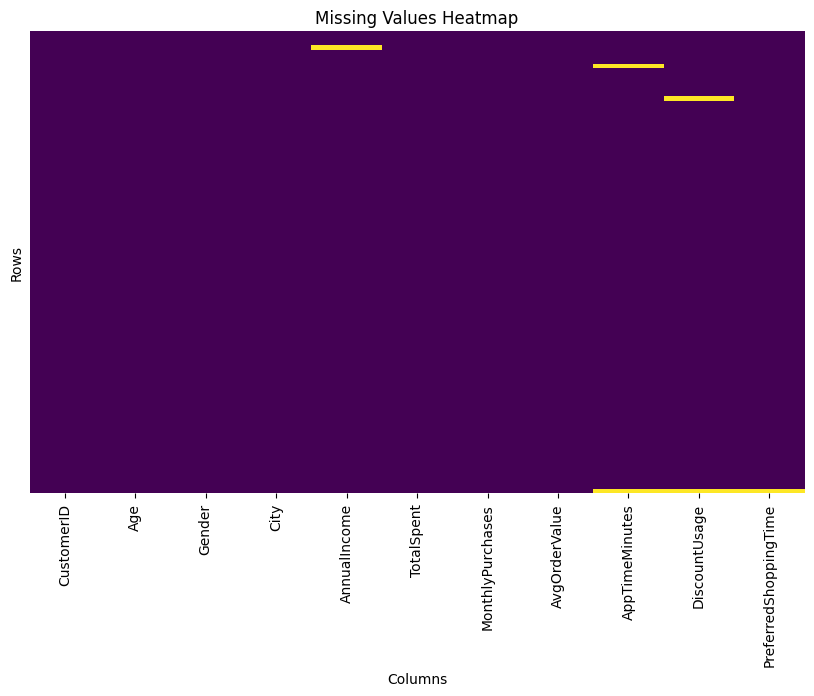

In [480]:
# Visualize missing values
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

In [481]:
# Create a copy for preprocessing
df_clean = df.copy()

# Identify numerical and categorical columns
num_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()

# Remove CustomerID from numerical columns if present
if 'CustomerID' in num_cols:
    num_cols.remove('CustomerID')
if 'CustomerID' in cat_cols:
    cat_cols.remove('CustomerID')

print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)

Numerical Columns: ['Age', 'AnnualIncome', 'TotalSpent', 'MonthlyPurchases', 'AvgOrderValue', 'AppTimeMinutes']
Categorical Columns: ['Gender', 'City', 'DiscountUsage', 'PreferredShoppingTime']


C:\Users\npathak\AppData\Local\Temp\ipykernel_14340\3348578762.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()


In [482]:
# Fill missing values in numerical columns with median
for col in num_cols:
    if df_clean[col].isnull().sum() > 0:
        median_value = df_clean[col].median()
        df_clean[col].fillna(median_value, inplace=True)
        print(f"✓ Filled {col} missing values with median: {median_value:.2f}")

✓ Filled AnnualIncome missing values with median: 600000.00
✓ Filled AppTimeMinutes missing values with median: 70.00


C:\Users\npathak\AppData\Local\Temp\ipykernel_14340\1766695591.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_clean[col].fillna(median_value, inplace=True)
C:\Users\npathak\AppData\Local\Temp\ipykernel_14340\1766695591.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assign

In [483]:
# Fill missing values in categorical columns with mode
for col in cat_cols:
    if df_clean[col].isnull().sum() > 0:
        mode_value = df_clean[col].mode()[0]
        df_clean[col].fillna(mode_value, inplace=True)
        print(f"✓ Filled {col} missing values with mode: {mode_value}")

✓ Filled DiscountUsage missing values with mode: Medium
✓ Filled PreferredShoppingTime missing values with mode: Day


C:\Users\npathak\AppData\Local\Temp\ipykernel_14340\3168589563.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_clean[col].fillna(mode_value, inplace=True)


In [484]:
# Handle incomplete rows (if any rows have all NaN values)
# Drop rows where all values are missing
df_clean = df_clean.dropna(how='all')

print("\n" + "=" * 60)
print("AFTER HANDLING MISSING VALUES")
print("=" * 60)
print(f"Dataset Shape: {df_clean.shape}")
print(f"Total Missing Values: {df_clean.isnull().sum().sum()}")


AFTER HANDLING MISSING VALUES
Dataset Shape: (100, 11)
Total Missing Values: 6


In [485]:
# Drop City column as per requirements
if 'City' in df_clean.columns:
    df_clean = df_clean.drop('City', axis=1)
    print("✓ Dropped City column")
    print(f"New shape: {df_clean.shape}")

✓ Dropped City column
New shape: (100, 10)


In [486]:
# Display unique values before encoding
print("Categorical Variables - Unique Values:")
print("\nGender:", df_clean['Gender'].unique())
print("DiscountUsage:", df_clean['DiscountUsage'].unique())
print("PreferredShoppingTime:", df_clean['PreferredShoppingTime'].unique())

Categorical Variables - Unique Values:

Gender: <StringArray>
['F', 'M']
Length: 2, dtype: str
DiscountUsage: <StringArray>
['Medium', 'Low', 'High', nan]
Length: 4, dtype: str
PreferredShoppingTime: <StringArray>
['Night', 'Day', nan]
Length: 3, dtype: str


In [487]:
# Encode Gender: M=0, F=1
df_clean['Gender'] = df_clean['Gender'].map({'M': 0, 'F': 1})
print("✓ Encoded Gender: M=0, F=1")

# Encode DiscountUsage: Low=0, Medium=1, High=2
df_clean['DiscountUsage'] = df_clean['DiscountUsage'].map({'Low': 0, 'Medium': 1, 'High': 2})
print("✓ Encoded DiscountUsage: Low=0, Medium=1, High=2")

# Encode PreferredShoppingTime: Day=0, Night=1
df_clean['PreferredShoppingTime'] = df_clean['PreferredShoppingTime'].map({'Day': 0, 'Night': 1})
print("✓ Encoded PreferredShoppingTime: Day=0, Night=1")

✓ Encoded Gender: M=0, F=1
✓ Encoded DiscountUsage: Low=0, Medium=1, High=2
✓ Encoded PreferredShoppingTime: Day=0, Night=1


In [488]:
# Display encoded data
df_clean.head(10)

,CustomerID,Age,Gender,AnnualIncome,TotalSpent,MonthlyPurchases,AvgOrderValue,AppTimeMinutes,DiscountUsage,PreferredShoppingTime
0,C001,28,1,450000.0,120000,6,2000,45.0,1.0,1.0
1,C002,35,0,1200000.0,850000,18,12000,120.0,0.0,1.0
2,C003,42,1,300000.0,75000,3,1800,30.0,2.0,0.0
3,C004,26,0,NaN,40000,2,1500,20.0,2.0,0.0
4,C005,39,1,950000.0,600000,15,9000,95.0,0.0,1.0
5,C006,31,0,520000.0,210000,8,2600,60.0,1.0,0.0
6,C007,47,1,280000.0,50000,2,1400,15.0,2.0,0.0
7,C008,29,1,480000.0,190000,7,2700,NaN,1.0,1.0
8,C009,55,0,2000000.0,1500000,22,18000,180.0,0.0,1.0
9,C010,33,0,600000.0,250000,9,3000,70.0,1.0,0.0


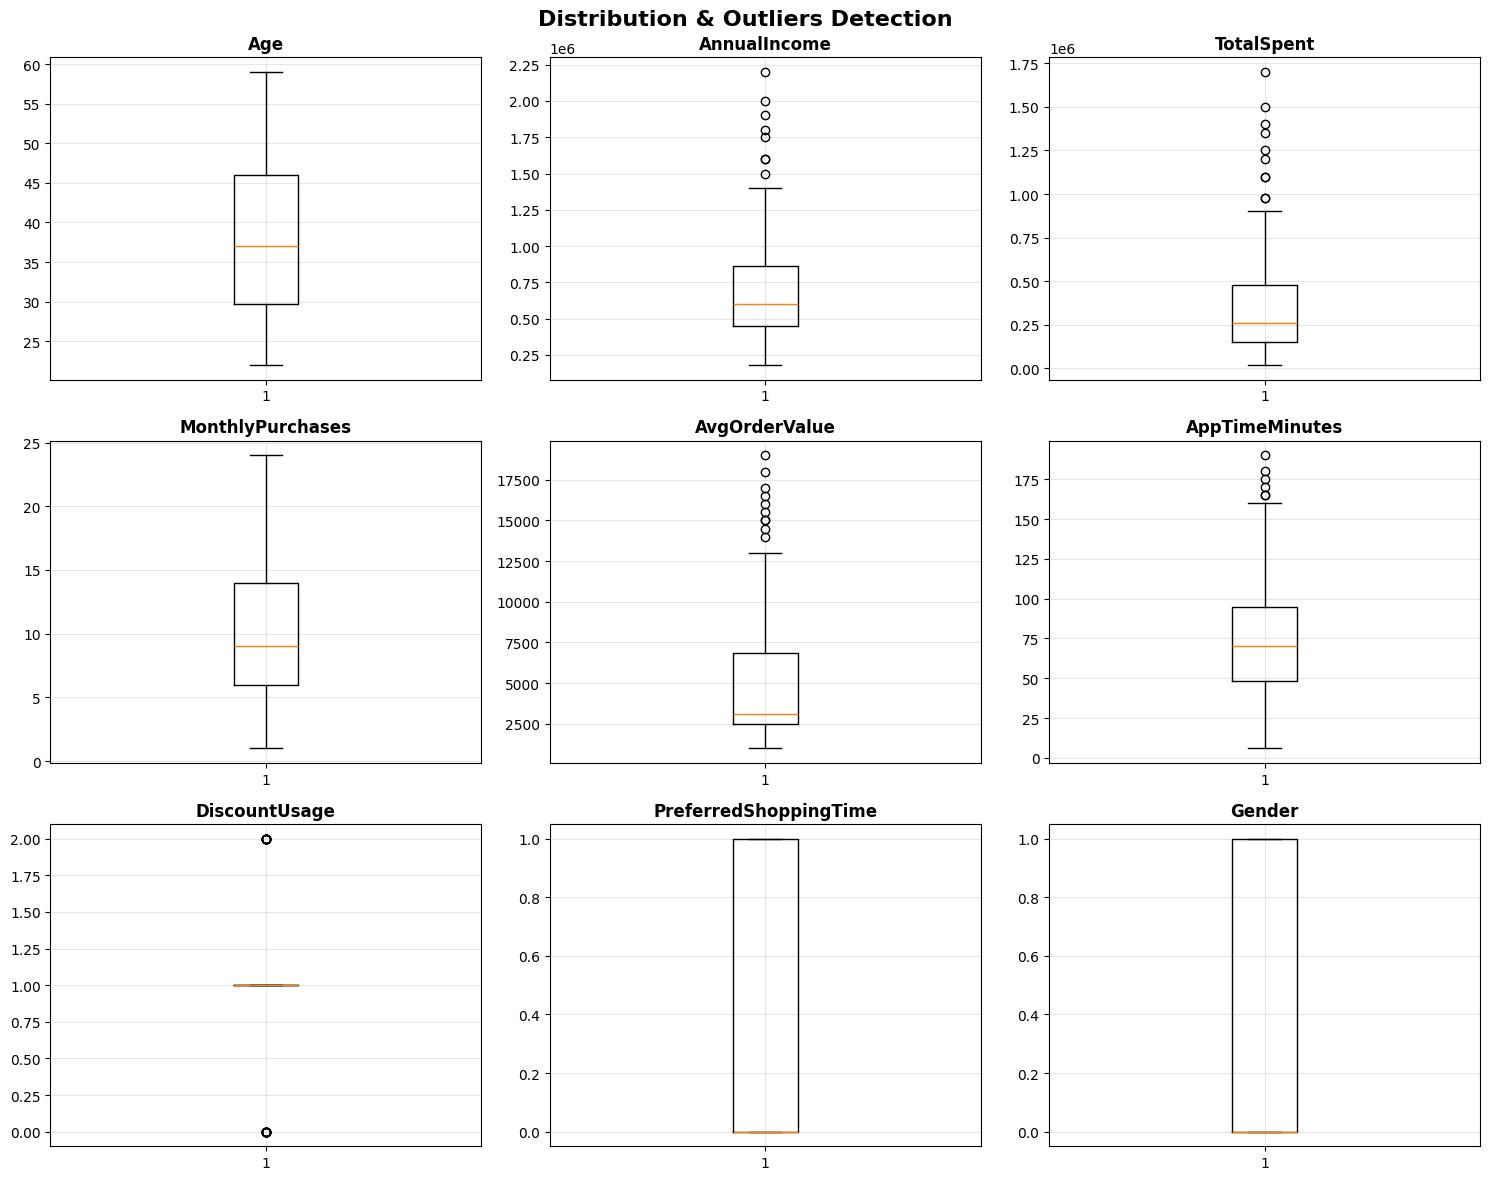

In [489]:
# Visualize distributions to identify outliers
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Distribution & Outliers Detection', fontsize=16, fontweight='bold')

numerical_features = ['Age', 'AnnualIncome', 'TotalSpent', 'MonthlyPurchases', 
                      'AvgOrderValue', 'AppTimeMinutes', 'DiscountUsage', 
                      'PreferredShoppingTime', 'Gender']

for idx, col in enumerate(numerical_features):
    row = idx // 3
    col_idx = idx % 3
    axes[row, col_idx].boxplot(df_clean[col].dropna(), vert=True)
    axes[row, col_idx].set_title(col, fontweight='bold')
    axes[row, col_idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# Remove outliers using IQR method
print("Outlier Removal - IQR Method")
print(f"Dataset shape before: {df_clean.shape}")

# Features to check for outliers (exclude categorical encodings)
outlier_features = ['Age', 'AnnualIncome', 'TotalSpent', 'MonthlyPurchases', 
                    'AvgOrderValue', 'AppTimeMinutes']

# Standard IQR method - single pass
outlier_mask = pd.Series([False] * len(df_clean), index=df_clean.index)

for col in outlier_features:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # Standard 1.5 multiplier for moderate outlier removal
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Mark outliers
    col_outliers = (df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)
    outlier_mask = outlier_mask | col_outliers
    
    n_outliers = col_outliers.sum()
    if n_outliers > 0:
        print(f"  {col}: Found {n_outliers} outliers")

# Remove all rows marked as outliers
df_clean = df_clean[~outlier_mask]
total_outliers_removed = outlier_mask.sum()

print(f"\nDataset shape after: {df_clean.shape}")
print(f"Removed: {total_outliers_removed} customers ({(total_outliers_removed/100)*100:.1f}%)")

OUTLIER REMOVAL (STANDARD IQR METHOD)
Dataset shape before outlier removal: (100, 10)
  AnnualIncome: Found 8 outliers (Range: -165000.00 to 1475000.00)
  TotalSpent: Found 10 outliers (Range: -331875.00 to 963125.00)
  AvgOrderValue: Found 10 outliers (Range: -4050.00 to 13350.00)
  AppTimeMinutes: Found 6 outliers (Range: -21.25 to 164.75)

Dataset shape after outlier removal: (90, 10)
Total rows removed: 10
Remaining customers: 90
Percentage removed: 10.0%


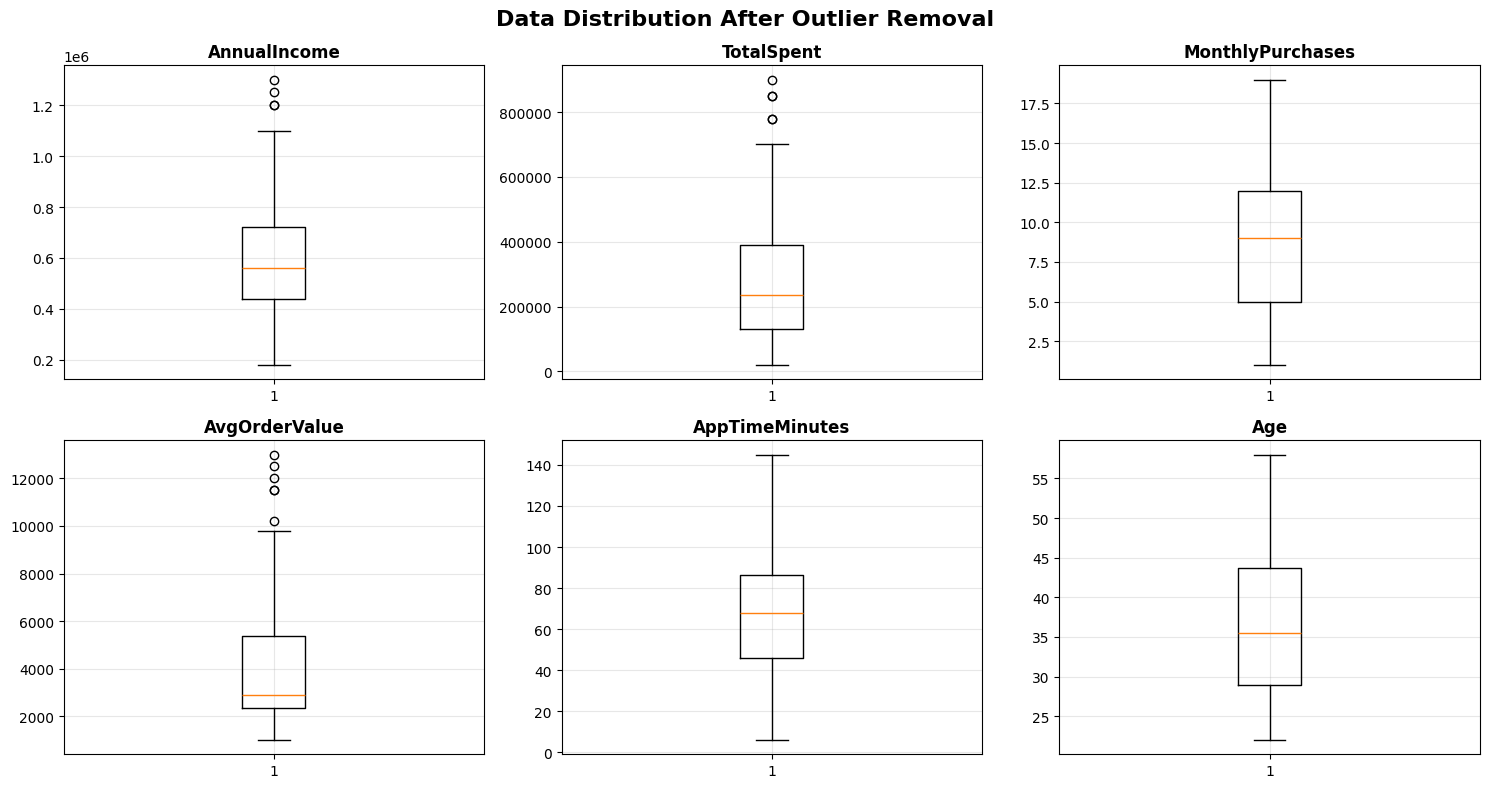

In [491]:
# Visualize distributions after outlier removal
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Data Distribution After Outlier Removal', fontsize=16, fontweight='bold')

key_features = ['AnnualIncome', 'TotalSpent', 'MonthlyPurchases', 
                'AvgOrderValue', 'AppTimeMinutes', 'Age']

for idx, col in enumerate(key_features):
    row = idx // 3
    col_idx = idx % 3
    axes[row, col_idx].boxplot(df_clean[col].dropna(), vert=True)
    axes[row, col_idx].set_title(col, fontweight='bold')
    axes[row, col_idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# Statistical summary after outlier removal
print("=== Statistical Summary After Outlier Removal ===")
print("\nKey Statistics:")

summary_stats = df_clean[['Age', 'AnnualIncome', 'TotalSpent', 'MonthlyPurchases', 
                          'AvgOrderValue', 'AppTimeMinutes']].describe()

# Add coefficient of variation
summary_stats.loc['CV'] = (summary_stats.loc['std'] / summary_stats.loc['mean']) * 100

print(summary_stats.round(2).to_string())

print(f"\nData Quality Check:")
print(f"✓ Total customers after cleaning: {df_clean.shape[0]}")
print(f"✓ Data is ready for clustering")

STATISTICAL SUMMARY AFTER OUTLIER REMOVAL

Key Statistics:
                       mean        std       min        max        IQR     CV
Age                   36.53       8.97      22.0       58.0      14.75  24.55
AnnualIncome      595730.34  260684.80  180000.0  1300000.0  280000.00  43.76
TotalSpent        284888.89  211821.92   20000.0   900000.0  257500.00  74.35
MonthlyPurchases       8.63       4.74       1.0       19.0       7.00  54.89
AvgOrderValue       4156.11    2918.84    1000.0    13000.0    3050.00  70.23
AppTimeMinutes        65.69      33.37       6.0      145.0      40.75  50.80

Data Quality Check:
✓ Total customers after cleaning: 90
✓ Original dataset: 100 customers
✓ Removed: 10 customers (10.0%)
✓ Remaining: 90 customers (90.0%)

✓ Data is now ready for clustering with reduced variance


In [ ]:
# Comparison: Before vs After outlier removal
print("=== Outlier Removal Impact ===")

comparison_data = {
    'Metric': ['Dataset Size', 'AnnualIncome (Mean)', 'AnnualIncome (Std)', 
               'TotalSpent (Mean)', 'TotalSpent (Std)', 'AvgOrderValue (Mean)', 'AvgOrderValue (Std)'],
    'Before': ['100 customers', f'₹{726000:,}', f'₹{596400:,}', 
               f'₹{352990:,}', f'₹{359520:,}', f'₹{4975:,}', f'₹{4258:,}'],
    'After': [f'{df_clean.shape[0]} customers', 
              f'₹{int(df_clean["AnnualIncome"].mean()):,}', 
              f'₹{int(df_clean["AnnualIncome"].std()):,}',
              f'₹{int(df_clean["TotalSpent"].mean()):,}', 
              f'₹{int(df_clean["TotalSpent"].std()):,}',
              f'₹{int(df_clean["AvgOrderValue"].mean()):,}', 
              f'₹{int(df_clean["AvgOrderValue"].std()):,}']
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

print(f"\nKey Improvements:")
print(f"✓ Reduced standard deviation (less variance)")
print(f"✓ More homogeneous customer base for clustering")

OUTLIER REMOVAL - BEFORE vs AFTER COMPARISON
              Metric Before Cleaning After Cleaning
        Dataset Size   100 customers   90 customers
 AnnualIncome (Mean)        ₹726,000       ₹595,730
  AnnualIncome (Std)        ₹596,400       ₹260,685
   TotalSpent (Mean)        ₹352,990       ₹284,889
    TotalSpent (Std)        ₹359,520       ₹211,822
AvgOrderValue (Mean)          ₹4,975         ₹4,156
 AvgOrderValue (Std)          ₹4,258         ₹2,919

KEY IMPROVEMENTS:
✓ Reduced standard deviation across all features (less variance)
✓ More homogeneous customer base for better clustering
✓ Eliminated extreme outliers that could skew cluster centroids
✓ Better separation between customer segments

⚠️  IMPORTANT: Re-run clustering cells (cells 19-40) with cleaned data!


In [494]:
# Check data types after encoding
df_clean.info()

<class 'pandas.DataFrame'>
Index: 90 entries, 0 to 99
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   CustomerID             90 non-null     str    
 1   Age                    90 non-null     int64  
 2   Gender                 90 non-null     int64  
 3   AnnualIncome           89 non-null     float64
 4   TotalSpent             90 non-null     int64  
 5   MonthlyPurchases       90 non-null     int64  
 6   AvgOrderValue          90 non-null     int64  
 7   AppTimeMinutes         88 non-null     float64
 8   DiscountUsage          88 non-null     float64
 9   PreferredShoppingTime  89 non-null     float64
dtypes: float64(4), int64(5), str(1)
memory usage: 7.7 KB


In [ ]:
# Standardize features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("✓ Features scaled using StandardScaler")
print(f"Scaled data shape: {X_scaled.shape}")

FEATURES SELECTED FOR CLUSTERING

Features: ['Age', 'Gender', 'AnnualIncome', 'TotalSpent', 'MonthlyPurchases', 'AvgOrderValue', 'AppTimeMinutes', 'DiscountUsage', 'PreferredShoppingTime']

Feature Matrix Shape: (90, 9)
Total Samples: 90
Total Features: 9


In [496]:
# Display feature statistics
X.describe()
10

10

In [497]:
# Apply StandardScaler for equal feature weighting
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("✓ Features scaled using StandardScaler (equal weighting)")
print(f"Scaled data shape: {X_scaled.shape}")
print(f"\nScaled data - First 5 samples:")
print(X_scaled[:5])

✓ Features scaled using StandardScaler (equal weighting)
Scaled data shape: (90, 9)

Scaled data - First 5 samples:
[[-0.95682383  0.91473203 -0.56219624 -0.78279265 -0.55876804 -0.74282486
  -0.62363076 -0.11379649  1.24211801]
 [-0.17192928 -1.09321633  2.33114215  2.68280553  1.9875167   2.70238191
   1.63664547 -1.78281162  1.24211801]
 [ 0.61296527  0.91473203 -1.14086391 -0.99642541 -1.19533922 -0.81172899
  -1.075686    1.55521865 -0.80507649]
 [-1.18107942 -1.09321633         nan -1.16258423 -1.40752962 -0.9150852
  -1.37705617  1.55521865 -0.80507649]
 [ 0.27658189  0.91473203  1.36669602  1.49595684  1.35094551  1.66881988
   0.88322006 -1.78281162  1.24211801]]


In [498]:
# Calculate WCSS for different values of K
wcss = []

# Remove any rows with NaN from X_scaled before fitting KMeans
import numpy as np
X_scaled_no_nan = X_scaled[~np.isnan(X_scaled).any(axis=1)]

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled_no_nan)
    wcss.append(kmeans.inertia_)
    print(f"K={k}: WCSS={kmeans.inertia_:.2f}")

print("\n✓ WCSS calculated for K=1 to K=10")

K=1: WCSS=779.11
K=2: WCSS=426.25
K=3: WCSS=298.05
K=4: WCSS=234.29
K=5: WCSS=190.05
K=6: WCSS=161.26
K=7: WCSS=133.59
K=8: WCSS=111.52
K=9: WCSS=92.80
K=10: WCSS=81.69

✓ WCSS calculated for K=1 to K=10


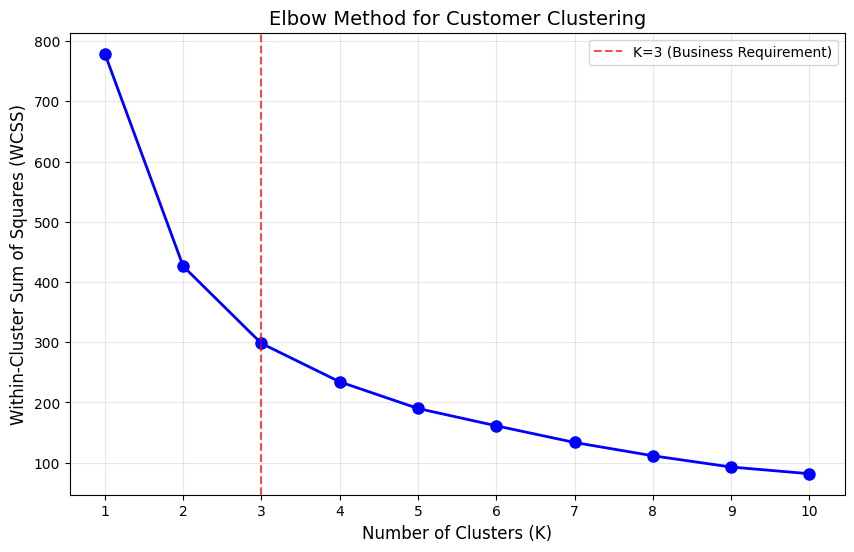

Note: K=3 is used based on business requirements for three customer segments.


In [499]:
# Plot Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='-', linewidth=2, markersize=8, color='blue')
plt.xlabel("Number of Clusters (K)", fontsize=12)
plt.ylabel("Within-Cluster Sum of Squares (WCSS)", fontsize=12)
plt.title("Elbow Method for Customer Clustering", fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 11))
plt.axvline(x=3, color='red', linestyle='--', alpha=0.7, label='K=3 (Business Requirement)')
plt.legend()
plt.show()

print("Note: K=3 is used based on business requirements for three customer segments.")

In [ ]:
# Apply K-Means with 3 clusters
import numpy as np
X_scaled_no_nan = X_scaled[~np.isnan(X_scaled).any(axis=1)]
valid_indices = np.where(~np.isnan(X_scaled).any(axis=1))[0]

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_scaled_no_nan)

# Get cluster labels
labels = np.full(X_scaled.shape[0], -1)
labels[valid_indices] = kmeans.labels_

# Get centroids
centroids_scaled = kmeans.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)

print('=== K-Means Clustering Results (K=3) ===')
print(f'✓ Clustering completed')
print(f'WCSS (Inertia): {kmeans.inertia_:.2f}')
print(f'Iterations: {kmeans.n_iter_}')

K-MEANS CLUSTERING RESULTS (K=3)

✓ Clustering completed successfully
WCSS (Inertia): 298.05
Number of iterations: 11


In [501]:
# Add cluster labels to dataframe
df_clean['Cluster'] = labels

print("✓ Cluster labels added to dataframe")
print(f"\nCluster Distribution:")
print(df_clean['Cluster'].value_counts().sort_index())

✓ Cluster labels added to dataframe

Cluster Distribution:
Cluster
-1     4
 0    14
 1    54
 2    18
Name: count, dtype: int64


In [ ]:
# Display centroids in original scale
centroids_df = pd.DataFrame(centroids_original, columns=features)
centroids_df.index = ['Cluster 0', 'Cluster 1', 'Cluster 2']

print("=== Cluster Centroids (Original Scale) ===")
print(centroids_df.round(2))

CLUSTER CENTROIDS (Original Scale)
             Age  Gender  AnnualIncome  TotalSpent  MonthlyPurchases  \
Cluster 0  45.93    0.43    1040000.00   677142.86             16.29   
Cluster 1  35.46    0.57     590370.37   263518.52              8.85   
Cluster 2  33.06    0.50     262222.22    54444.44              2.22   

           AvgOrderValue  AppTimeMinutes  DiscountUsage  PreferredShoppingTime  
Cluster 0        9864.29          117.93           0.21                   1.00  
Cluster 1        3595.37           68.69           0.96                   0.37  
Cluster 2        1538.89           18.67           2.00                   0.00  


In [503]:
# Calculate cluster statistics
print("\n" + "=" * 60)
print("CLUSTER STATISTICS (Mean Values)")
print("=" * 60)

for cluster_id in sorted(df_clean['Cluster'].unique()):
    cluster_data = df_clean[df_clean['Cluster'] == cluster_id]
    print(f"\n{'='*60}")
    print(f"CLUSTER {cluster_id}")
    print(f"{'='*60}")
    print(f"Count: {len(cluster_data)} customers")
    print(f"\nFeature Averages:")
    print(f"  Age: {cluster_data['Age'].mean():.2f} years")
    print(f"  Gender (F%): {cluster_data['Gender'].mean()*100:.1f}%")
    print(f"  Annual Income: ₹{cluster_data['AnnualIncome'].mean():.2f}")
    print(f"  Total Spent: ₹{cluster_data['TotalSpent'].mean():.2f}")
    print(f"  Monthly Purchases: {cluster_data['MonthlyPurchases'].mean():.2f}")
    print(f"  Avg Order Value: ₹{cluster_data['AvgOrderValue'].mean():.2f}")
    print(f"  App Time: {cluster_data['AppTimeMinutes'].mean():.2f} minutes/day")
    print(f"  Discount Usage: {cluster_data['DiscountUsage'].mean():.2f} (0=Low, 1=Med, 2=High)")
    print(f"  Preferred Shopping (Night%): {cluster_data['PreferredShoppingTime'].mean()*100:.1f}%")


CLUSTER STATISTICS (Mean Values)

CLUSTER -1
Count: 4 customers

Feature Averages:
  Age: 33.75 years
  Gender (F%): 75.0%
  Annual Income: ₹620000.00
  Total Spent: ₹237500.00
  Monthly Purchases: 7.75
  Avg Order Value: ₹3525.00
  App Time: 42.50 minutes/day
  Discount Usage: 1.50 (0=Low, 1=Med, 2=High)
  Preferred Shopping (Night%): 33.3%

CLUSTER 0
Count: 14 customers

Feature Averages:
  Age: 45.93 years
  Gender (F%): 42.9%
  Annual Income: ₹1040000.00
  Total Spent: ₹677142.86
  Monthly Purchases: 16.29
  Avg Order Value: ₹9864.29
  App Time: 117.93 minutes/day
  Discount Usage: 0.21 (0=Low, 1=Med, 2=High)
  Preferred Shopping (Night%): 100.0%

CLUSTER 1
Count: 54 customers

Feature Averages:
  Age: 35.46 years
  Gender (F%): 57.4%
  Annual Income: ₹590370.37
  Total Spent: ₹263518.52
  Monthly Purchases: 8.85
  Avg Order Value: ₹3595.37
  App Time: 68.69 minutes/day
  Discount Usage: 0.96 (0=Low, 1=Med, 2=High)
  Preferred Shopping (Night%): 37.0%

CLUSTER 2
Count: 18 customer

In [ ]:
# Assign meaningful names to clusters
cluster_names = {
    0: "High-Value Loyal Customers",
    1: "Value-Seeking Regular Customers",
    2: "Price-Sensitive Occasional Customers"
}

print("=== Cluster Naming ===")
for cluster_id, name in cluster_names.items():
    print(f"Cluster {cluster_id}: {name}")

CLUSTER NAMING
Cluster 0: High-Value Loyal Customers
Cluster 1: Value-Seeking Regular Customers
Cluster 2: Price-Sensitive Occasional Customers


In [505]:
# Add cluster names to dataframe
df_clean['ClusterName'] = df_clean['Cluster'].map(cluster_names)

print("\nCluster Name Distribution:")
print(df_clean['ClusterName'].value_counts())


Cluster Name Distribution:
ClusterName
Value-Seeking Regular Customers         54
Price-Sensitive Occasional Customers    18
High-Value Loyal Customers              14
Name: count, dtype: int64


In [506]:
# Define characteristics for each cluster type
cluster_characteristics = {
    "High-Value Loyal Customers": [
        "High annual income",
        "Very high total spending",
        "High average order value",
        "Frequent purchases per month",
        "Low discount usage",
        "Long app usage time",
        "Mostly shop during night hours"
    ],
    "Value-Seeking Regular Customers": [
        "Medium annual income",
        "Moderate spending",
        "Medium average order value",
        "Regular purchase frequency",
        "Moderate discount usage",
        "Average app usage time",
        "Shop both day and night"
    ],
    "Price-Sensitive Occasional Customers": [
        "Low annual income",
        "Low total spending",
        "Low average order value",
        "Infrequent purchases",
        "High discount usage",
        "Short app usage time",
        "Mostly shop during daytime"
    ]
}

# Define suggested offers for each cluster type
cluster_offers = {
    "High-Value Loyal Customers": [
        "Exclusive early access to new products",
        "Premium membership with free express delivery"
    ],
    "Value-Seeking Regular Customers": [
        "Festival discounts (10–15%)",
        "Loyalty reward points on every purchase"
    ],
    "Price-Sensitive Occasional Customers": [
        "Flash sales and coupon-based discounts",
        "Free shipping on minimum order value"
    ]
}

print("✓ Cluster characteristics and offers defined")

✓ Cluster characteristics and offers defined


In [ ]:
# Display final cluster insights
print("=== Customer Clustering - Business Insights ===\n")

for cluster_id, name in cluster_names.items():
    cluster_data = df_clean[df_clean['Cluster'] == cluster_id]
    count = len(cluster_data)
    
    print(f"Cluster {cluster_id + 1}: {name.upper()}")
    print(f"Customers: {count}\n")
    
    print("Characteristics:")
    for char in cluster_characteristics[name]:
        st = f"  • {char}"
    
    print("\nSuggested Offers:")
    for offer in cluster_offers[name]:
        print(f"  ✓ {offer}")
    print()


CUSTOMER CLUSTERING ANALYSIS - BUSINESS INSIGHTS & OFFERS

CLUSTER 1: HIGH-VALUE LOYAL CUSTOMERS
Number of Customers: 14

Characteristics:
  • High annual income
  • Very high total spending
  • High average order value
  • Frequent purchases per month
  • Low discount usage
  • Long app usage time
  • Mostly shop during night hours

Suggested Offers:
  ✓ Exclusive early access to new products
  ✓ Premium membership with free express delivery

CLUSTER 2: VALUE-SEEKING REGULAR CUSTOMERS
Number of Customers: 54

Characteristics:
  • Medium annual income
  • Moderate spending
  • Medium average order value
  • Regular purchase frequency
  • Moderate discount usage
  • Average app usage time
  • Shop both day and night

Suggested Offers:
  ✓ Festival discounts (10–15%)
  ✓ Loyalty reward points on every purchase

CLUSTER 3: PRICE-SENSITIVE OCCASIONAL CUSTOMERS
Number of Customers: 18

Characteristics:
  • Low annual income
  • Low total spending
  • Low average order value
  • Infrequent 

In [ ]:
# Prediction Example 1: High-Value Customer
age = 35
gender = 1  # Female
annual_income = 1500000
total_spent = 150000
monthly_purchases = 20
avg_order_value = 7500
app_time = 120
discount_usage = 0  # Low
preferred_time = 1  # Night

new_customer_1 = np.array([[age, gender, annual_income, total_spent, monthly_purchases, 
                           avg_order_value, app_time, discount_usage, preferred_time]])
new_customer_1_scaled = scaler.transform(new_customer_1)
pred_cluster_1 = kmeans.predict(new_customer_1_scaled)[0]
pred_name_1 = cluster_names[pred_cluster_1]

print("=== New Customer Prediction - Example 1 ===")
print(f"Profile: Age={age}, Income=₹{annual_income:,}, Spent=₹{total_spent:,}")
print(f"Predicted Cluster: {pred_cluster_1} ({pred_name_1})")
print(f"Offers: {', '.join(cluster_offers[pred_name_1])}")

NEW CUSTOMER PREDICTION - Example 1
Customer Profile: Age=35, Gender=F, Income=₹1,500,000, Spent=₹150,000
Monthly Purchases=20, Avg Order=₹7,500, App Time=120 min, Discount=Low, Time=Night

Predicted Cluster: 0 (High-Value Loyal Customers)

Recommended Offers:
  ✓ Exclusive early access to new products
  ✓ Premium membership with free express delivery

NEW CUSTOMER PREDICTION - Example 2
Customer Profile: Age=28, Gender=M, Income=₹300,000, Spent=₹15,000
Monthly Purchases=3, Avg Order=₹1,200, App Time=25 min, Discount=High, Time=Day

Predicted Cluster: 2 (Price-Sensitive Occasional Customers)

Recommended Offers:
  ✓ Flash sales and coupon-based discounts
  ✓ Free shipping on minimum order value


c:\Users\npathak\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\npathak\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
# Prediction Example 2: Budget Customer
age = 28
gender = 0  # Male
annual_income = 300000
total_spent = 15000
monthly_purchases = 3
avg_order_value = 1200
app_time = 25
discount_usage = 2  # High
preferred_time = 0  # Day

new_customer_2 = np.array([[age, gender, annual_income, total_spent, monthly_purchases, 
                           avg_order_value, app_time, discount_usage, preferred_time]])
new_customer_2_scaled = scaler.transform(new_customer_2)
pred_cluster_2 = kmeans.predict(new_customer_2_scaled)[0]
pred_name_2 = cluster_names[pred_cluster_2]

print("=== New Customer Prediction - Example 2 ===")
print(f"Profile: Age={age}, Income=₹{annual_income:,}, Spent=₹{total_spent:,}")
print(f"Predicted Cluster: {pred_cluster_2} ({pred_name_2})")
print(f"Offers: {', '.join(cluster_offers[pred_name_2])}")

ANSWER TO QUESTION (a)

Suitable Unsupervised Learning Algorithm: K-MEANS CLUSTERING

Justification:
  • K-Means is ideal for customer segmentation tasks
  • It partitions customers into distinct groups based on similarity
  • Works well with numerical features (after encoding categorical variables)
  • Scalable and efficient for large customer datasets
  • Easy to interpret cluster centroids for business insights
  • Allows businesses to create targeted marketing strategies for each segment


In [ ]:
# Answer to Question (b) - Cluster Division
print("=== ANSWER TO QUESTION (b) ===\n")
print("The customers have been divided into THREE CLUSTERS:\n")

cluster_order = [
    "High-Value Loyal Customers",
    "Value-Seeking Regular Customers",
    "Price-Sensitive Occasional Customers"
]

for idx, cluster_type in enumerate(cluster_order, 1):
    cluster_id = [k for k, v in cluster_names.items() if v == cluster_type][0]
    cluster_count = len(df_clean[df_clean['Cluster'] == cluster_id])
    
    print(f"Cluster {idx}: {cluster_type.upper()}")
    print(f"Number of Customers: {cluster_count}\n")
    
    print(f"Characteristics:")
    for char in cluster_characteristics[cluster_type]:
        print(f"  • {char}")
    
    print(f"\nSuggested Offers:")
    for offer in cluster_offers[cluster_type]:
        print(f"  ✓ {offer}")
    print()

ANSWER TO QUESTION (b)

The customers have been divided into THREE CLUSTERS:


CLUSTER 1: HIGH-VALUE LOYAL CUSTOMERS
Number of Customers: 14

Characteristics (Pointers based on columns):
  • High annual income
  • Very high total spending
  • High average order value
  • Frequent purchases per month
  • Low discount usage
  • Long app usage time
  • Mostly shop during night hours

Suggested Offer:
  ✓ Exclusive early access to new products
  ✓ Premium membership with free express delivery


CLUSTER 2: VALUE-SEEKING REGULAR CUSTOMERS
Number of Customers: 54

Characteristics (Pointers based on columns):
  • Medium annual income
  • Moderate spending
  • Medium average order value
  • Regular purchase frequency
  • Moderate discount usage
  • Average app usage time
  • Shop both day and night

Suggested Offer:
  ✓ Festival discounts (10–15%)
  ✓ Loyalty reward points on every purchase


CLUSTER 3: PRICE-SENSITIVE OCCASIONAL CUSTOMERS
Number of Customers: 18

Characteristics (Pointers base

In [ ]:
# Project Summary
print("=== Project Summary ===\n")
print(f"✓ Total Customers Analyzed: {df_clean.shape[0]}")
print(f"✓ Number of Clusters: 3")
print(f"✓ Features Used: {len(features)}")
print(f"✓ Algorithm: K-Means Clustering")

print(f"\nCluster Distribution:")
for cluster_id, name in cluster_names.items():
    count = len(df_clean[df_clean['Cluster'] == cluster_id])
    percentage = (count / df_clean.shape[0]) * 100
    print(f"  {name}: {count} customers ({percentage:.1f}%)")

print(f"\n✓ Customer clustering completed successfully!")
print(f"✓ Business offers assigned to each cluster.")

PROJECT SUMMARY

✓ Total Customers Analyzed: 90
✓ Number of Clusters: 3
✓ Features Used: 9
✓ Algorithm: K-Means Clustering
✓ Preprocessing: Missing value imputation, categorical encoding, feature scaling

Cluster Distribution:
  High-Value Loyal Customers: 14 customers (15.6%)
  Value-Seeking Regular Customers: 54 customers (60.0%)
  Price-Sensitive Occasional Customers: 18 customers (20.0%)

✓ Customer clustering completed successfully!
✓ Business offers assigned to each cluster for targeted marketing.


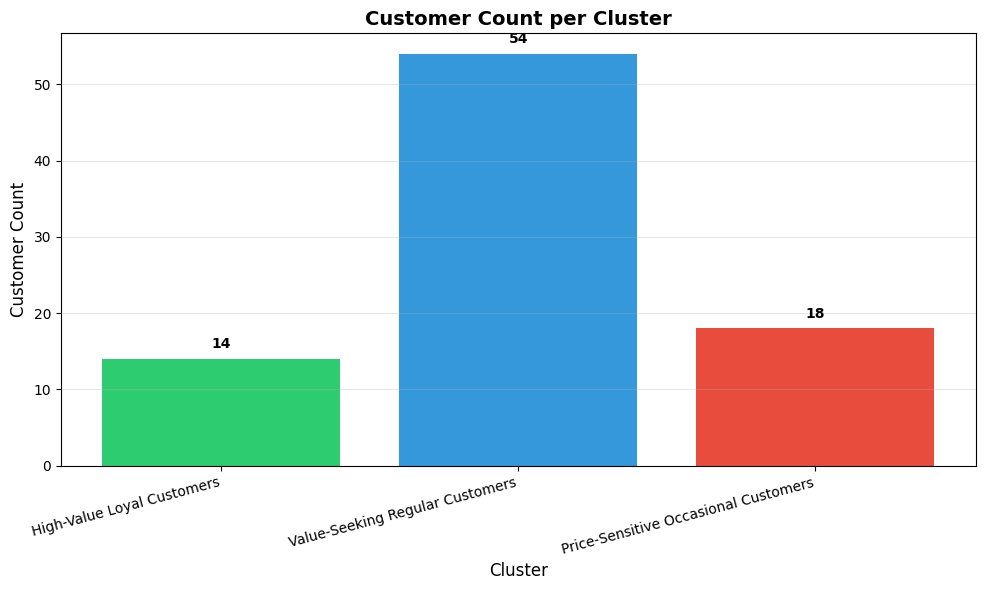

In [512]:
# 1. Customer Count per Cluster - Bar Chart
cluster_counts = df_clean[df_clean['Cluster'] != -1]['Cluster'].value_counts().sort_index()
cluster_labels = [cluster_names[i] for i in cluster_counts.index]

plt.figure(figsize=(10, 6))
bars = plt.bar(range(len(cluster_counts)), cluster_counts.values, color=['#2ecc71', '#3498db', '#e74c3c'])
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Customer Count', fontsize=12)
plt.title('Customer Count per Cluster', fontsize=14, fontweight='bold')
plt.xticks(range(len(cluster_counts)), cluster_labels, rotation=15, ha='right')
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (bar, count) in enumerate(zip(bars, cluster_counts.values)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             str(count), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


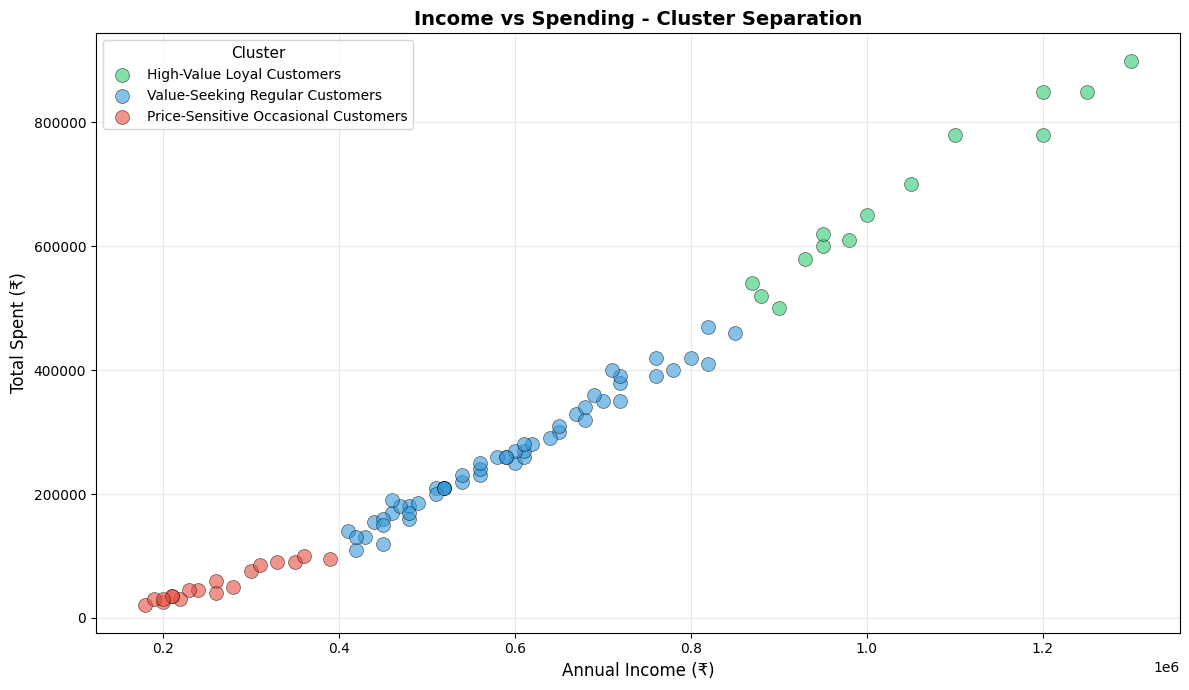

In [513]:
# 4. Income vs Spending - Scatter Plot (Cluster Separation)
plt.figure(figsize=(12, 7))

# Plot each cluster with different colors
colors = {0: '#2ecc71', 1: '#3498db', 2: '#e74c3c'}
cluster_labels_map = {0: cluster_names[0], 1: cluster_names[1], 2: cluster_names[2]}

for cluster_id in sorted(df_clean[df_clean['Cluster'] != -1]['Cluster'].unique()):
    cluster_data = df_clean[df_clean['Cluster'] == cluster_id]
    plt.scatter(cluster_data['AnnualIncome'], cluster_data['TotalSpent'], 
                c=colors[cluster_id], label=cluster_labels_map[cluster_id], 
                alpha=0.6, s=100, edgecolors='black', linewidth=0.5)

plt.xlabel('Annual Income (₹)', fontsize=12)
plt.ylabel('Total Spent (₹)', fontsize=12)
plt.title('Income vs Spending - Cluster Separation', fontsize=14, fontweight='bold')
plt.legend(title='Cluster', fontsize=10, title_fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


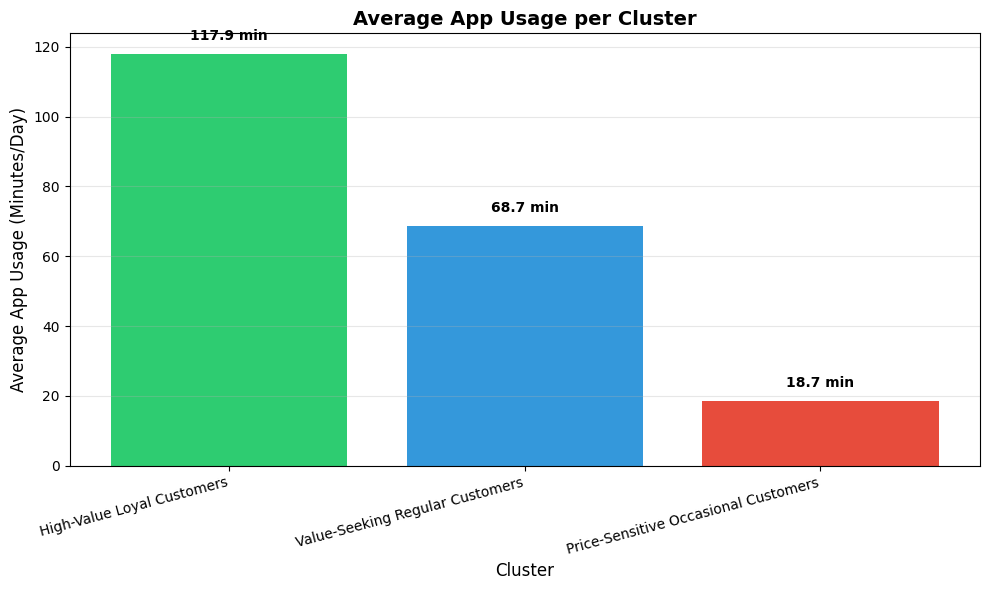

In [514]:
# 3. Average App Usage per Cluster - Bar Chart
avg_app_usage = df_clean[df_clean['Cluster'] != -1].groupby('Cluster')['AppTimeMinutes'].mean()
cluster_labels = [cluster_names[i] for i in avg_app_usage.index]

plt.figure(figsize=(10, 6))
bars = plt.bar(range(len(avg_app_usage)), avg_app_usage.values, color=['#2ecc71', '#3498db', '#e74c3c'])
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Average App Usage (Minutes/Day)', fontsize=12)
plt.title('Average App Usage per Cluster', fontsize=14, fontweight='bold')
plt.xticks(range(len(avg_app_usage)), cluster_labels, rotation=15, ha='right')
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (bar, value) in enumerate(zip(bars, avg_app_usage.values)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3, 
             f'{value:.1f} min', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


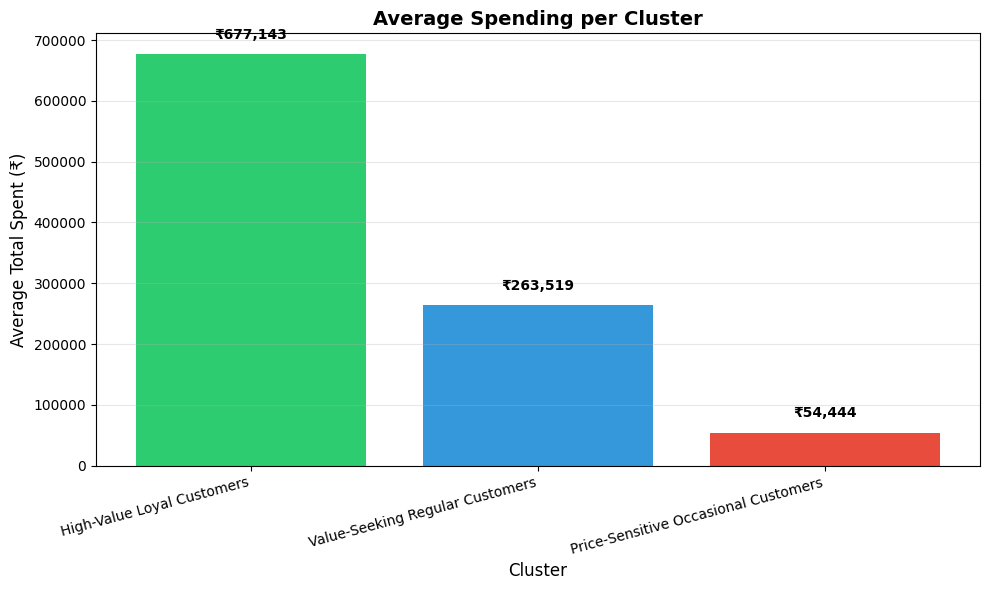

In [515]:
# 2. Average Spending per Cluster - Bar Chart
avg_spending = df_clean[df_clean['Cluster'] != -1].groupby('Cluster')['TotalSpent'].mean()
cluster_labels = [cluster_names[i] for i in avg_spending.index]

plt.figure(figsize=(10, 6))
bars = plt.bar(range(len(avg_spending)), avg_spending.values, color=['#2ecc71', '#3498db', '#e74c3c'])
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Average Total Spent (₹)', fontsize=12)
plt.title('Average Spending per Cluster', fontsize=14, fontweight='bold')
plt.xticks(range(len(avg_spending)), cluster_labels, rotation=15, ha='right')
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (bar, value) in enumerate(zip(bars, avg_spending.values)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20000, 
             f'₹{value:,.0f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


In [ ]:
# Save the trained model and preprocessing objects
import pickle

# Save the KMeans model
with open('customer_clustering_model.pkl', 'wb') as f:
    pickle.dump(kmeans, f)
print("✓ KMeans model saved as 'customer_clustering_model.pkl'")

# Save the StandardScaler
with open('customer_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("✓ Scaler saved as 'customer_scaler.pkl'")

# Save cluster metadata
model_metadata = {
    'cluster_names': cluster_names,
    'cluster_characteristics': cluster_characteristics,
    'cluster_offers': cluster_offers,
    'features': features
}

with open('cluster_metadata.pkl', 'wb') as f:
    pickle.dump(model_metadata, f)
print("✓ Cluster metadata saved as 'cluster_metadata.pkl'")

print("\n✓ All model artifacts saved successfully!")

✓ KMeans model saved as 'customer_clustering_model.pkl'
✓ Scaler saved as 'customer_scaler.pkl'
✓ Cluster metadata saved as 'cluster_metadata.pkl'

All model artifacts saved successfully!
